# **SM2ST Automatic Registration**

In [1]:
# import my_package.rectification as rectification
msi_file="/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_MSI/V11L12-109_B1.Visium.FMP.220826_smamsi.csv"
st_path="/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_RNA/outs/"
msi_path="/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_MSI/"
import importlib
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import SM2ST

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# seed_everything()
seed=2025
SM2ST.rectification.fix_seed(seed)

## **1 Read MSI**

62 77


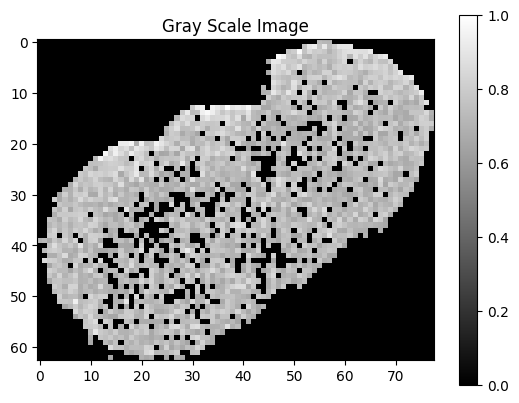

In [3]:
ms_org=pd.read_csv(msi_file)
ms_sp=ms_org.copy()
print(np.max(ms_sp.loc[:,"x"]),np.max(ms_sp.loc[:,"y"]))
ms=SM2ST.rectification.msi_sum(ms_sp,0.65)
SM2ST.rectification.tensor_viewer(ms)

### **1.1 Registration feature selection (optional)**

In [4]:
# # 计算每一行的总和（从第3列开始）
# row_sums = ms_sp.iloc[:,2:].sum(axis=1)

# # 删除总和为0的行
# ms_n = ms_sp[row_sums >= 1e6]

In [5]:
# from scipy.sparse import csr_matrix, csc_matrix, coo_matrix
# ms_intensity = csr_matrix(ms_n.iloc[:,2:], dtype=np.float32)
# print(ms_intensity.shape)
# ms_adata = ad.AnnData(ms_intensity)
# ms_adata.obs["array_row"]=ms_n.iloc[:,0] ##raw x
# ms_adata.obs["array_col"]=ms_n.iloc[:,1] ##raw y
# ms_adata.var_names=ms_n.iloc[:,2:].columns
# ms_adata.obsm["spatial"]=ms_n.loc[:,["x","y"]].to_numpy()
# # ms_adata.obs_names=ms_n.index

In [6]:
# import squidpy as sq
# sq.gr.spatial_neighbors(ms_adata)
# sq.gr.spatial_autocorr(ms_adata, mode="moran", genes=ms_adata.var_names)

In [7]:
# high_moran_genes2 = ms_adata.uns['moranI']['I'][(ms_adata.uns['moranI']['I'] > 0.5) & (ms_adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
# adata_high_moran2 = ms_adata[:, high_moran_genes2]
# adata_high_moran2.var_names

In [8]:
# import scanpy as sc
# sc.pp.highly_variable_genes(ms_adata, flavor="seurat_v3", n_top_genes=100)
# columns_to_sum = ms_adata[:, ms_adata.var['highly_variable']].var_names

In [9]:
# def standard(vec_1):
#     return (vec_1-min(vec_1))/(max(vec_1)-min(vec_1))

# def msi_sum(ms, threshold, columns_to_sum):
#     """
#     对指定的列进行求和，并生成标准化后的矩阵

#     参数:
#     ms -- 包含x, y坐标和多列数据的DataFrame
#     threshold -- 标准化后值的阈值，低于此阈值的将被设为0
#     columns_to_sum -- 要进行求和的列名列表

#     返回:
#     ms_sum -- 标准化后并应用阈值的矩阵
#     """
#     # 选择特定的列进行求和
#     if columns_to_sum is None:
#         # 如果没有指定列，则对所有列进行求和
#         ms_n = pd.concat([ms.loc[:, ["x", "y"]], ms.iloc[:, 2:].sum(axis=1)], axis=1)
#     else:
#         # 如果指定了列，则只对这些列进行求和
#         ms_n = pd.concat([ms.loc[:, ["x", "y"]], ms[columns_to_sum].sum(axis=1)], axis=1)

#     ms_n.columns = ["x", "y", "sum"]

#     # 对求和后的值进行标准化
#     ms_n.loc[:, "sum_standard"] = standard(ms_n.loc[:, "sum"])

#     # 构建矩阵
#     ms_sum_matrix = ms_n.pivot(index='x', columns='y', values="sum_standard")

#     # 应用阈值in_tissue
#     ms_sum = np.where(ms_sum_matrix < threshold, 0, ms_sum_matrix)

#     return ms_sum

In [10]:
# ms=msi_sum(ms_sp,0.0,adata_high_moran2.var_names)
# rectification.tensor_viewer(ms)

### **1.2 Affine transformation**

In [11]:
org_size=ms.shape

In [12]:
org_size

(63, 78)

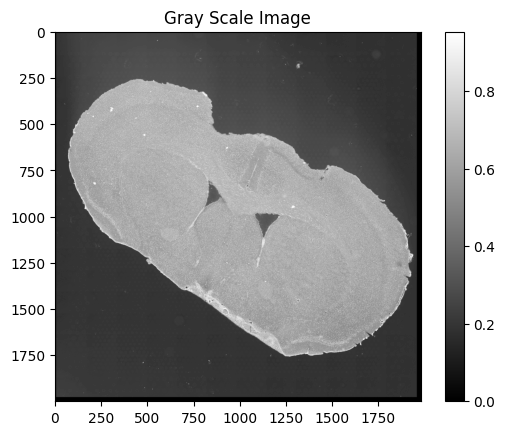

In [13]:
image_path = '/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_RNA/outs/spatial/tissue_hires_image.png'

normalized_gray_image=SM2ST.rectification.he_img(image_path)
SM2ST.rectification.tensor_viewer(normalized_gray_image)

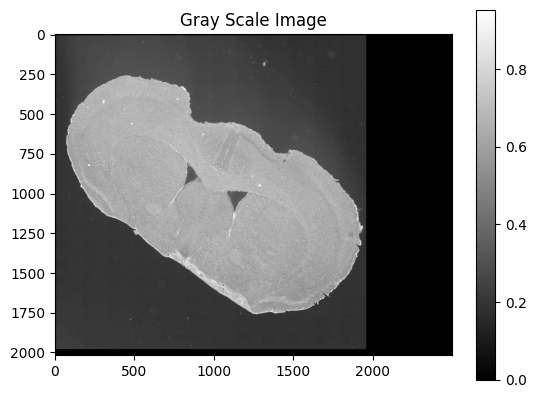

In [14]:
HE_tensor,msi_tensor,rate=SM2ST.rectification.he_padding(ms,normalized_gray_image,0.)#fill 0
SM2ST.rectification.tensor_viewer(HE_tensor)

In [15]:
target_size=np.array(HE_tensor.shape[2:4])
target_size

array([2016, 2496])

In [16]:
device=torch.device("cuda")

In [17]:
fit_af=SM2ST.rectification.fit(device=device,num_epochs=1000)
fit_af.train_AF(msi_tensor,HE_tensor,list(target_size))#train

  0%|                                            | 0/1000 [00:00<?, ?it/s]/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/torch/nn/functional.py:4227: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
100%|████████████████████████████████| 1000/1000 [00:02<00:00, 399.84it/s]


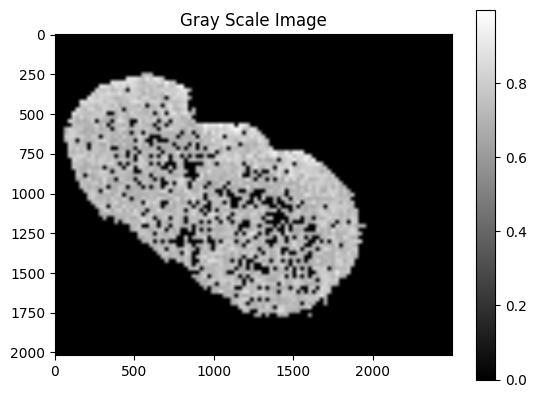

torch.Size([1, 1, 2016, 2496])


In [18]:
af_msi=fit_af.net(msi_tensor.to(device))
SM2ST.rectification.tensor_viewer(af_msi.cpu().detach())
print(af_msi.shape)

In [19]:
af_theta=fit_af.net.theta.squeeze().cpu().detach()
print(af_theta)

tensor([[-1.3135,  0.0000, -0.2547],
        [ 0.0000,  1.3135, -0.0023]])


In [20]:
ms_org_x_y = torch.tensor(np.array(ms_sp.loc[:,["y","x"]]),dtype=torch.float32)

ms_he = SM2ST.torch_af_transfor(af_theta,target_size,org_size,ms_org_x_y)

ms_he

tensor([[1956.0956,  242.3572],
        [1931.7336,  242.3572],
        [1907.3721,  242.3572],
        ...,
        [ 128.9605, 1752.7889],
        [ 104.5986, 1752.7889],
        [  80.2369, 1752.7889]])

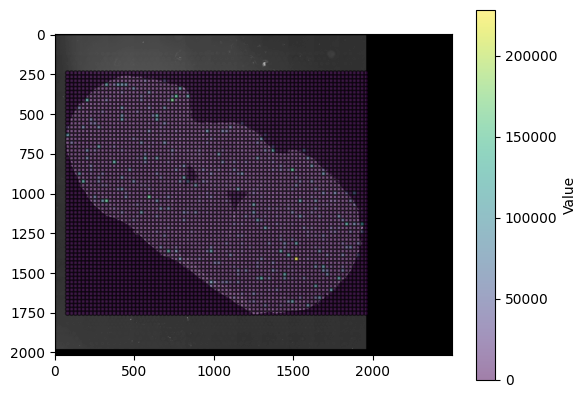

In [21]:
ms_sp.loc[:,["he_x","he_y"]]=ms_he.numpy()
plt.imshow(HE_tensor.squeeze().detach().cpu(), cmap='gray')
scatter = plt.scatter(ms_sp['he_x'], 
                    ms_sp['he_y'], 
                    c=ms_sp['156.26059'], 
                    cmap='viridis', 
                    s=10,
                    alpha=0.5,
                    edgecolor='k')

plt.colorbar(scatter, label='Value')

In [22]:
ms_sp

,x,y,156.26059,156.26195,156.48344,156.4838,156.485,157.54681,158.41217,160.02547,...,1046.31366,1046.32671,1046.33977,1046.36442,1048.32025,1048.3319,1048.34354,1048.38431,he_x,he_y
0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1956.095581,242.357224
1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1931.733643,242.357224
2,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1907.372070,242.357224
3,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1883.010132,242.357224
4,0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1858.648315,242.357224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4909,62,73,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,177.684067,1752.788940
4910,62,74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,153.322235,1752.788940
4911,62,75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,128.960480,1752.788940
4912,62,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,104.598640,1752.788940


## **2 Mapping Metabolomic Information onto Transcriptomic Coordinates**

In [23]:
ms_adata = SM2ST.ms2anndata(ms_org = ms_org,ms_sp = ms_sp,HE_path = image_path,in_tissue=True)

In [25]:
# from PIL import Image
# image_path = '/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_RNA/outs/spatial/tissue_hires_image.png'
# image = Image.open(image_path)
# image_array = np.array(image)
# spatial_key = "spatial"
# library_id = "tissue42"  # 你可以自定义这个 ID
# ms_adata.uns[spatial_key] = {library_id: {}}
# ms_adata.uns[spatial_key][library_id]["images"] = {"hires": image_array}
# ms_adata.uns[spatial_key][library_id]["scalefactors"] = {
#     "tissue_hires_scalef": 1,  
#     "spot_diameterres_full": 0.5, 
#     'fiducial_diameter_fullres': 609.8565193216596,
#     'spot_diameter_fullres': 377.5302262467417
# }

In [26]:
ms_adata

AnnData object with n_obs × n_vars = 3005 × 1538
    obs: 'array_row', 'array_col'
    uns: 'spatial'
    obsm: 'spatial'

In [27]:
import scanpy as sc
st_adata=sc.read_visium(st_path,
               count_file='filtered_feature_bc_matrix.h5',
               source_image_path="tissue_hires_image.png")
st_adata

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3120 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [28]:
st_adata.uns['spatial']['V11L12-109_B1']['scalefactors']['tissue_hires_scalef']

0.04155585

In [29]:
st_adata.uns['spatial']['V11L12-109_B1']['scalefactors']['tissue_lowres_scalef']/st_adata.uns['spatial']['V11L12-109_B1']['scalefactors']['tissue_hires_scalef']

0.30000002406400067

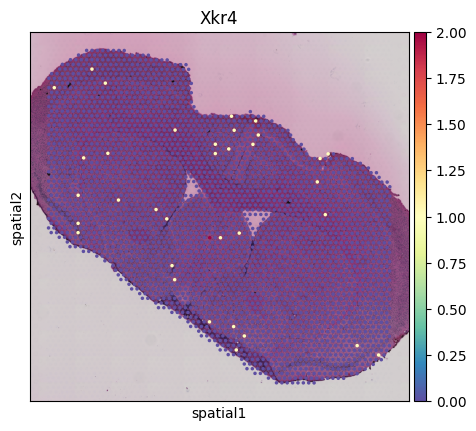

In [30]:
sc.pl.spatial(st_adata, 
              img_key="hires", 
              color=['Xkr4'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=1,
              spot_size=None,
              bw=False, 
              alpha_img=1)

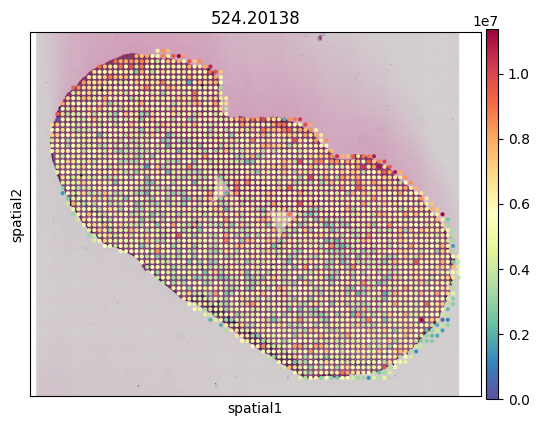

In [32]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['524.20138'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

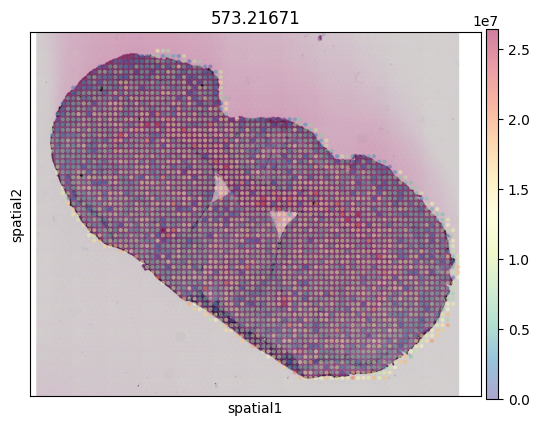

In [33]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['573.21671'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,alpha=0.5)

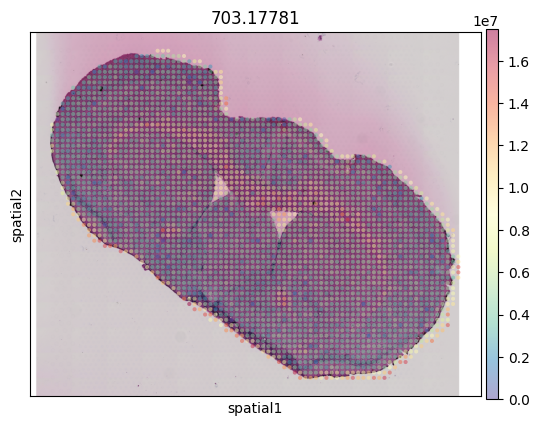

In [34]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['703.17781'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

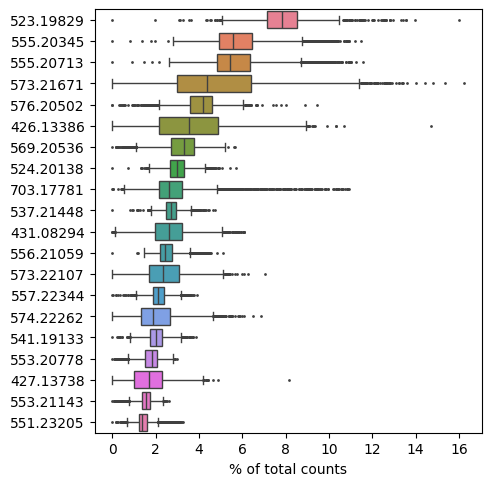

In [35]:
sc.pl.highest_expr_genes(ms_adata, n_top=20, )

In [36]:
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix
from PIL import Image
import anndata as ad
st_intensity = csr_matrix(st_adata.X.A, dtype=np.float32)
print(st_intensity.shape)
st_adata1 = ad.AnnData(st_intensity)
st_adata1.var_names=st_adata.var_names
st_adata1.obs_names=st_adata.obs_names
st_adata1.obs["array_row"]=st_adata.obs["array_row"]##raw x
st_adata1.obs["array_col"]=st_adata.obs["array_col"]##raw5 y
st_adata1.obsm["spatial"]=st_adata.obsm["spatial"]*0.04155585
from PIL import Image
image_path = '/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_RNA/outs/spatial/tissue_hires_image.png'
image = Image.open(image_path)
image_array = np.array(image)
spatial_key = "spatial"
library_id = "tV11L12-038_A1_c"  # You can customize this ID.
st_adata1.uns[spatial_key] = {library_id: {}}
st_adata1.uns[spatial_key][library_id]["images"] = {"hires": image_array}
st_adata1.uns[spatial_key][library_id]["scalefactors"] = {
    "tissue_hires_scalef": 1,  # Proportional factor between image pixels and spatial coordinates
    "spot_diameterres_full": 0.5, 
    'fiducial_diameter_fullres': 609.8565193216596,
    'spot_diameter_fullres': 377.5302262467417
}

(3120, 32285)


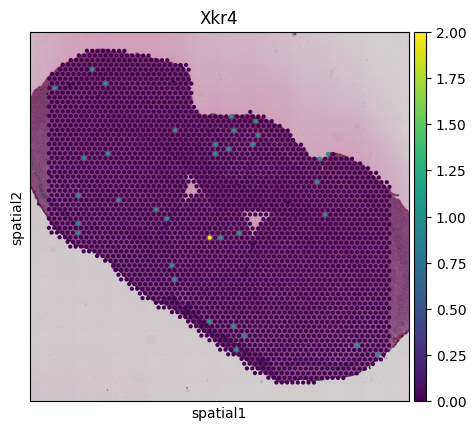

In [37]:
sc.pl.spatial(st_adata1, 
              img_key="hires", 
              color=['Xkr4'], 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)#color是一个感兴趣的基因的list

In [38]:
st_adata1.obsm['spatial']

array([[1443.650229  , 1273.72835835],
       [ 323.4707364 , 1123.9195191 ],
       [1382.77090875, 1504.19710245],
       ...,
       [1143.49232445,  874.54286325],
       [ 540.22605   , 1166.43115365],
       [ 831.57411435,  370.55351445]])

In [39]:
ms_adata.uns['coord'] = st_adata1.obsm['spatial']

<Axes: title={'center': '523.19829'}, xlabel='spatial1', ylabel='spatial2'>

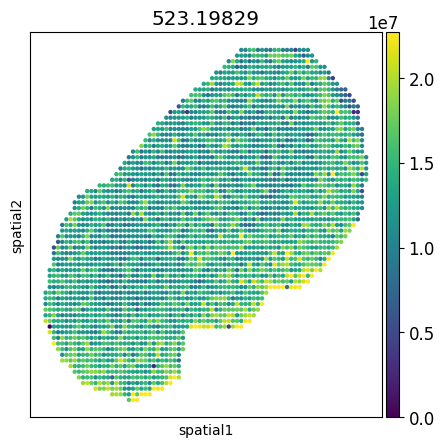

In [40]:
plot_gene = '523.19829'#
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '573.21671'}, xlabel='spatial1', ylabel='spatial2'>

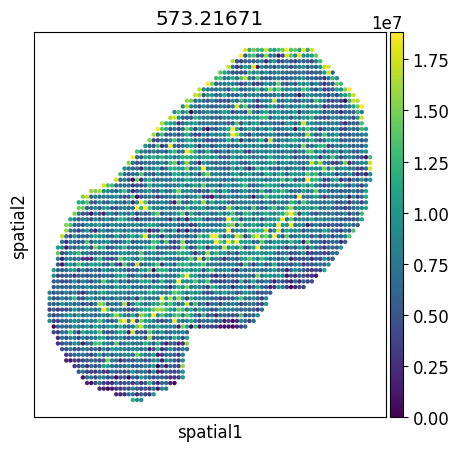

In [41]:
plot_gene = '573.21671'#
fig, ax = plt.subplots(figsize=(5, 5))  
plt.rcParams['font.size'] = 12  
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [42]:
# sc.pp.normalize_total(ms_adata, target_sum=1e3)
sc.pp.normalize_total(ms_adata, target_sum=1e4)
sc.pp.log1p(ms_adata)

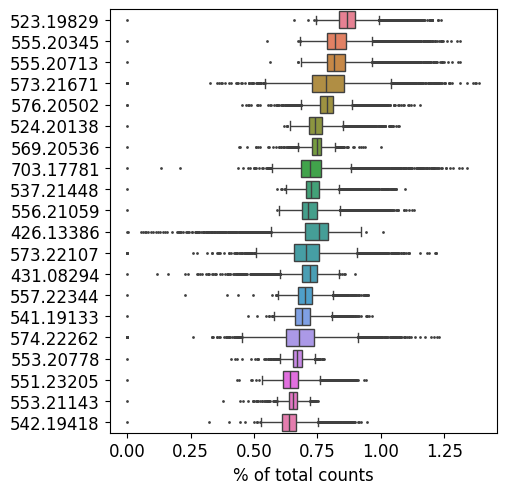

In [43]:
sc.pl.highest_expr_genes(ms_adata, n_top=20, )

<Axes: title={'center': '573.21671'}, xlabel='spatial1', ylabel='spatial2'>

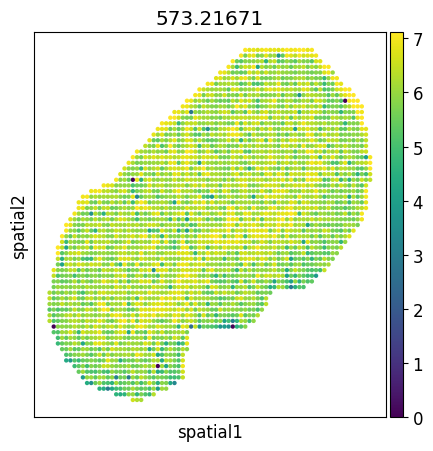

In [44]:
plot_gene = '573.21671'#
fig, ax = plt.subplots(figsize=(5, 5))  
plt.rcParams['font.size'] = 12 
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [46]:
adata_SMLED = SM2ST.train_SMLED(adata=ms_adata, mask_ratio=0., coord_sf=2.0, train_epoch=10000, experiment='generation', WMMSE=False)

Size of Input:  (3005, 1538)
80.23687744140625 242.3572235107422
pixel_step: 48.12174607170801
              0          1
0     12.137577   1.000000
1     11.631322   1.000000
2     11.125069   1.000000
3     13.656335   1.506253
4     13.150082   1.506253
...         ...        ...
3000  26.818924  32.387716
3001  26.312673  32.387716
3002  25.806419  32.387716
3003  25.300166  32.387716
3004  24.793912  32.387716

[3005 rows x 2 columns]               0          1
0     29.332583  22.432538
1      6.054552  19.319416
2     28.067472  27.221822
3     32.593372  20.263284
4     34.836029  24.189875
...         ...        ...
3115  19.848141  11.079359
3116   4.577870   9.730484
3117  23.095114  14.137213
3118  10.558863  20.202835
3119  16.613258   3.663999

[3120 rows x 2 columns]


Epochs: 100% 10000/10000 [13:49:34<00:00,  4.98s/it, loss_re: 0.20014, loss_lat: 1.14767, loss_GA: 0.00133, loss: 0.54578, loss_DA: 1.38347]  


In [83]:
import scipy
import seaborn as sns
def Probability_Density(ms_adata, adata_SMLED):
    
    if scipy.sparse.issparse(ms_adata.X):
        data = ms_adata.X.A.flatten()
    else:
        data = adata.X.A
    if scipy.sparse.issparse(adata_SMLED.X):
        data1 = adata_SMLED.X.A.flatten()
    else:
        data1 = adata_SMLED.X.A

    data_nonzero = data # [data != 0]
    data_nonzero1 = data1 # [data1 != 0]

    # sns.kdeplot(data_nonzero, shade=True)
    sns.kdeplot(data_nonzero, fill=True, alpha=0.5, label='Original Data', color='blue')
    sns.kdeplot(data_nonzero1, fill=True, alpha=0.5, label='Generated Data', color='orange')
    
    plt.title('Probability Density Distribution')
    plt.xlabel('Expression Level')
    plt.ylabel('Density')
    
    plt.show()

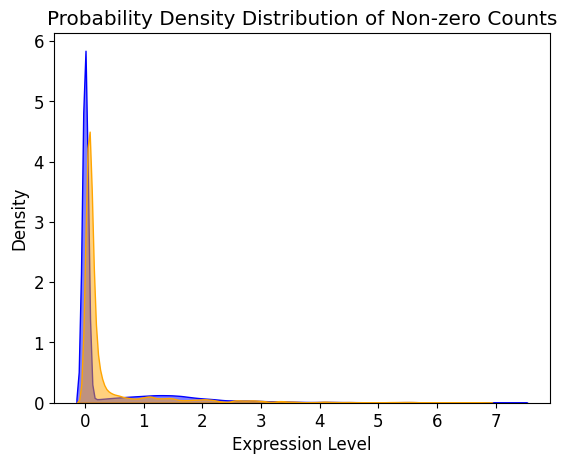

In [84]:
Probability_Density(ms_adata, adata_SMLED)

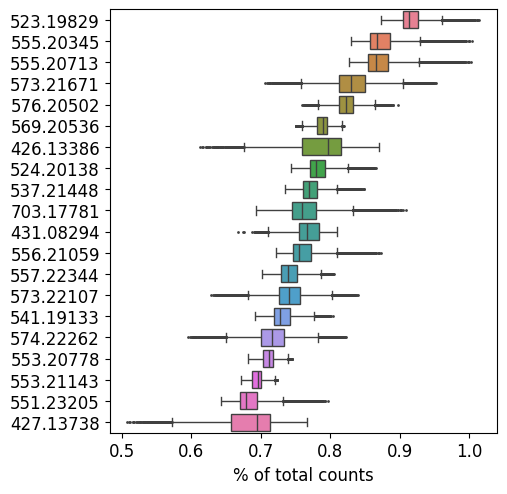

In [48]:
sc.pl.highest_expr_genes(adata_SMLED, n_top=20, )

<Axes: title={'center': '573.21671'}, xlabel='spatial1', ylabel='spatial2'>

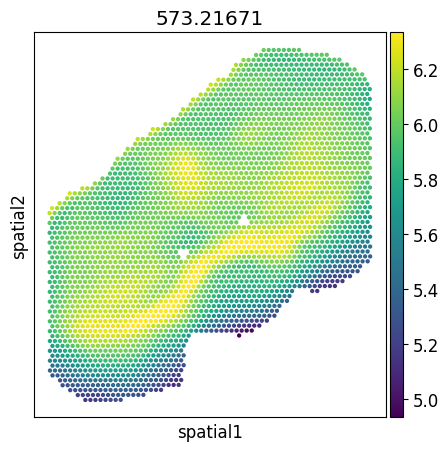

In [49]:
plot_gene = '573.21671'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12 
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '573.21671'}, xlabel='spatial1', ylabel='spatial2'>

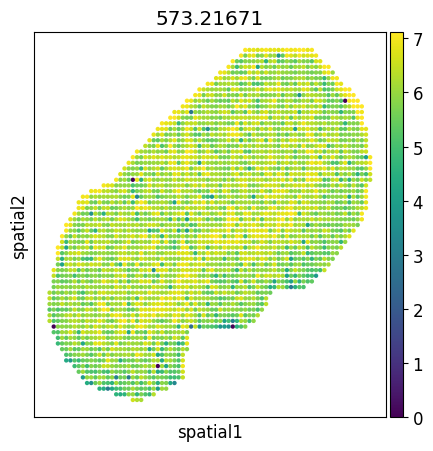

In [50]:
plot_gene = '573.21671'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12  
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [51]:
adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_SMLED_31__wmse3.h5ad')

In [52]:
# st_intensity = csr_matrix(st_adata.X.A, dtype=np.float32)
# print(st_intensity.shape)
# st_adata1 = ad.AnnData(st_intensity)
# st_adata1.var_names=st_adata.var_names
# st_adata1.obs_names=st_adata.obs_names
# st_adata1.obs["array_row"]=st_adata.obs["array_row"]##raw x
# st_adata1.obs["array_col"]=st_adata.obs["array_col"]##raw y
# st_adata1.obsm["spatial"]=st_adata.obsm["spatial"]*0.04155585
from PIL import Image
image_path = '/home/llx/project/MSI_data/sma/V11L12-109/V11L12-109_B1/output_data/V11L12-109_B1_RNA/outs/spatial/tissue_hires_image.png'
image = Image.open(image_path)
image_array = np.array(image)
spatial_key = "spatial"
library_id = "tV11L12-038_A1_c"  # 你可以自定义这个 ID
adata_SMLED.uns[spatial_key] = {library_id: {}}
adata_SMLED.uns[spatial_key][library_id]["images"] = {"hires": image_array}
adata_SMLED.uns[spatial_key][library_id]["scalefactors"] = {
    "tissue_hires_scalef": 1,  # Proportional factor between image pixels and spatial coordinates
    "spot_diameterres_full": 0.5,  # Diameter of each observation point
    'fiducial_diameter_fullres': 609.8565193216596,
    'spot_diameter_fullres': 377.5302262467417
}

### **2.1 Evaluate signal transfer**

In [53]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_SMLED)
sq.gr.spatial_autocorr(adata_SMLED, mode="moran", genes=adata_SMLED.var_names)
sq.gr.spatial_autocorr(adata_SMLED, mode="geary", genes=adata_SMLED.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [54]:
import squidpy as sq
sq.gr.spatial_neighbors(ms_adata)
sq.gr.spatial_autocorr(ms_adata, mode="moran", genes=ms_adata.var_names)
sq.gr.spatial_autocorr(ms_adata, mode="geary", genes=ms_adata.var_names)

In [72]:
ms_adata_high_moran_genes = ms_adata.uns['moranI']['I'][(ms_adata.uns['moranI']['I'] > 0.05) & (ms_adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = ms_adata[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = ms_adata.uns['gearyC']['C'][(ms_adata.uns['gearyC']['C'] < 0.9) & (ms_adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = ms_adata[:, ms_adata_high_geary_genes]

In [73]:
ms_adata_high_moran_genes = ms_adata.uns['moranI']['I'][(ms_adata.uns['moranI']['I'] > 0.05) & (ms_adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = ms_adata[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = ms_adata.uns['gearyC']['C'][(ms_adata.uns['gearyC']['C'] < 0.8) & (ms_adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = ms_adata[:, ms_adata_high_geary_genes]

In [74]:
adata_SMLED_high_moran_genes = adata_SMLED.uns['moranI']['I'][(adata_SMLED.uns['moranI']['I'] > 0.05) & (adata_SMLED.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_SMLED[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_SMLED.uns['gearyC']['C'][(adata_SMLED.uns['gearyC']['C'] < 0.8) & (adata_SMLED.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_SMLED[:, adata_SMLED_high_geary_genes]

In [75]:
ms_adata_set1 = set(ms_adata_high_geary.var_names)
ms_adata_set2 = set(ms_adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

In [76]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

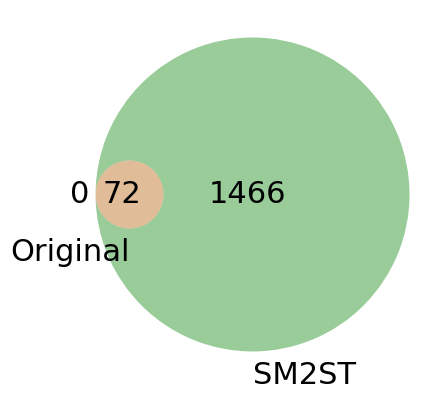

In [61]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

v = venn2([set1, set2], ('Original', 'SM2ST'))


v.get_label_by_id('010').set_position(( 0.0,  0.0))
v.get_label_by_id('110').set_position(( -0.45, 0.0))

v.get_label_by_id('100').set_position((-0.6,  0.0))

# 字体大小
for pid in ('100', '010', '110', 'A', 'B'):
    if v.get_label_by_id(pid):
        v.get_label_by_id(pid).set_fontsize(22)

plt.show()

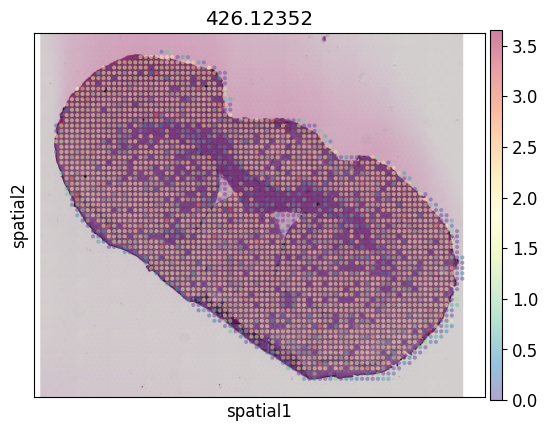

In [62]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['426.12352'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

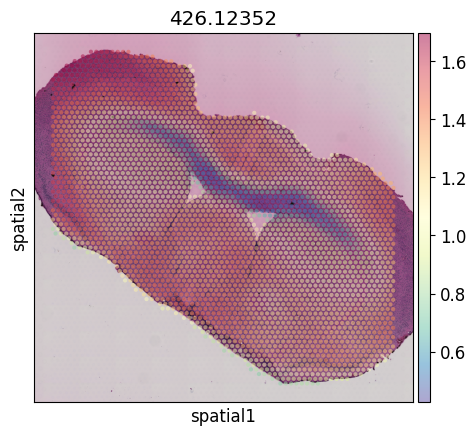

In [63]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['426.12352'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

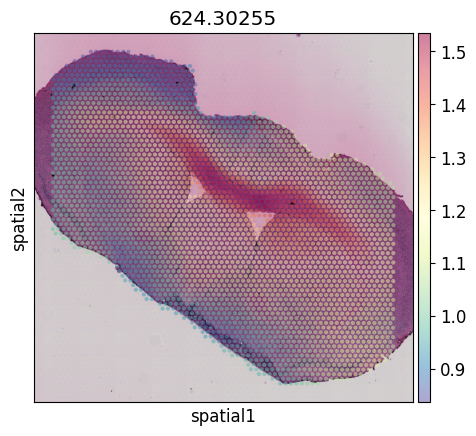

In [64]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['624.30255'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

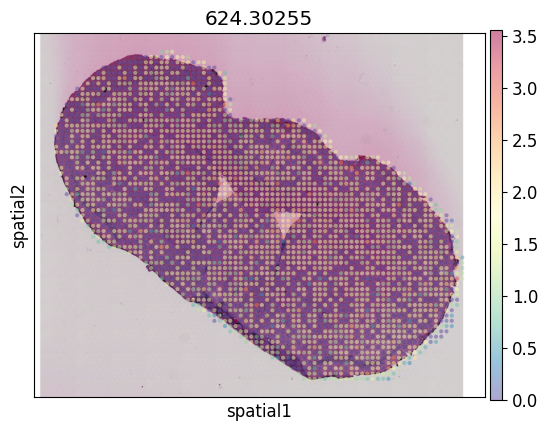

In [65]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['624.30255'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

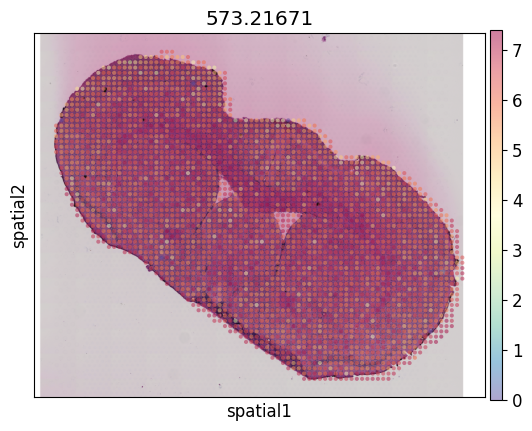

In [66]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['573.21671'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

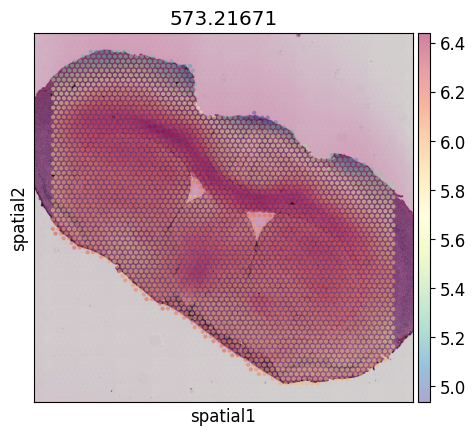

In [68]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['573.21671'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

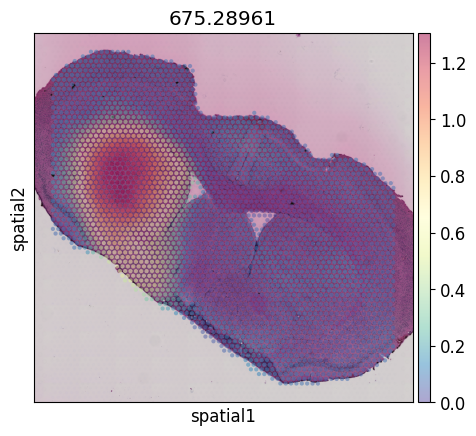

In [67]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['675.28961'], 
              cmap='Speactral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1,
            alpha=0.5)

In [69]:
ms_adata_va = ms_adata[:,list(ms_adata_v)]
adata_SMLED_va = adata_SMLED[:,list(ms_adata_v)]

In [70]:
ms_column_sums = np.sum(ms_adata_va.X.A, axis=0)
ms_m = ms_adata.X.A.shape[0]
ms_column_means = ms_column_sums / ms_m
SMLED_column_sums = np.sum(adata_SMLED_va.X.A, axis=0)
SMLED_m = ms_adata.X.A.shape[0]
SMLED_column_means = SMLED_column_sums / SMLED_m

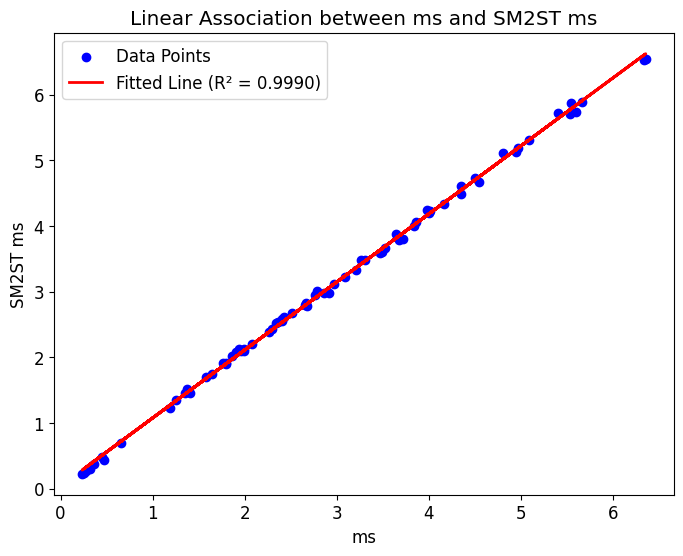

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = ms_column_means.reshape(-1, 1)
y = SMLED_column_means

model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted Line (R² = {r2:.4f})')
plt.xlabel('ms')
plt.ylabel('SM2ST ms')
plt.title('Linear Association between ms and SM2ST ms')
plt.legend()
# plt.grid(True)
plt.show()